#### Project Overview:
**- Task:** predict a number of a handwritten image

**- Train dataset:** MNIST: http://yann.lecun.com/exdb/mnist/ (train: 60k samples, test: 10k samples)

**- Feature types:** 28x28 pixels

**- Output:** predicted number

**- Pipeline:**\
(1) data setup and preprocessing\
(2) data analysis\
(3) train the DNN model\
(4) evaluate the model

In [63]:
import torchvision
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

##### 1. Data setup and preprocessing

In [64]:
image_path = './data'

transform = transforms.Compose([
    transforms.ToTensor(),
])

mnist_train_dataset = torchvision.datasets.MNIST(
    root = image_path,
    train = True,
    download = True,
    transform = transform
)

mnist_test_dataset = torchvision.datasets.MNIST(
    root = image_path,
    train = False,
    download = True,
    transform = transform
)

In [65]:
# dataloader
batch_size = 512
train_dl = DataLoader(mnist_train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
valid_dl = DataLoader(mnist_test_dataset, batch_size=batch_size)

##### 2. Data Analysis

In [66]:
# check sample shape
sample = train_dl.dataset[0]
print("feature shape: ", sample[0].shape)
print("label: ", sample[1])
print("number of class: ", len(torch.unique(mnist_test_dataset.targets)), 
      " - ", *torch.unique(mnist_test_dataset.targets).numpy())

feature shape:  torch.Size([1, 28, 28])
label:  5
number of class:  10  -  0 1 2 3 4 5 6 7 8 9


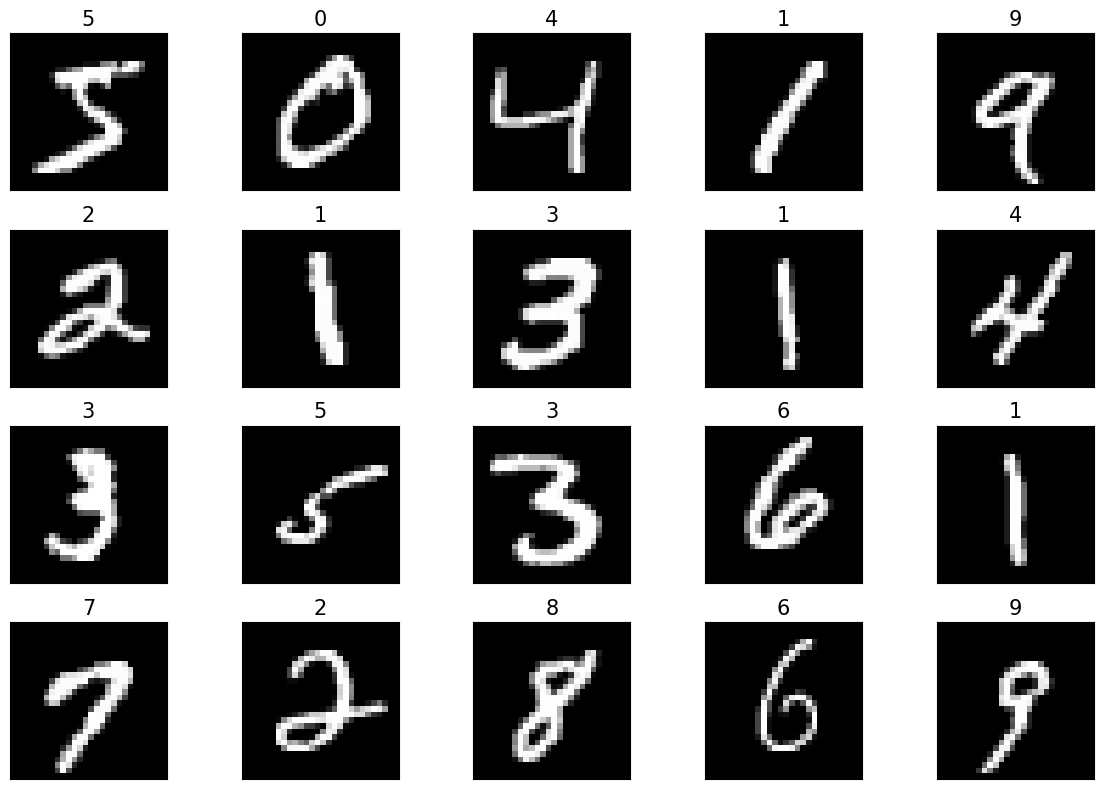

In [67]:
# visualize the image:
from itertools import islice
fig = plt.figure(figsize=(12, 8))

for i, (image, label) in islice(enumerate(mnist_train_dataset), 20):
    ax = fig.add_subplot(4, 5, i+1)
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(label, size=15)

plt.tight_layout()
plt.show()

##### 3. Train the model

In [68]:
# create the model
model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=2))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))

model.add_module('conv2', nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))

model

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [69]:
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 64, 7, 7])

In [70]:
model.add_module('flatten', nn.Flatten())
model.add_module('fc1', nn.Linear(64*7*7, 1024))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(p=0.3))
model.add_module('fc2', nn.Linear(1024, 10))

model

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=1024, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=1024, out_features=10, bias=True)
)

In [71]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

3274634


In [72]:
# create the model
loss_fn = nn.CrossEntropyLoss()

lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [73]:
# create train function
def train(model, train_dl: DataLoader, valid_dl: DataLoader, n_epochs: int = 100):
    loss_hist_train = []
    accuracy_hist_train = []
    loss_hist_valid = []
    accuracy_hist_valid = []

    for epoch in range(n_epochs):
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        for x_batch, y_batch in train_dl:
            # forward
            pred = model(x_batch)

            # loss
            loss = loss_fn(pred, y_batch)
            loss.backward()

            # update weight and bias:
            optimizer.step()
            optimizer.zero_grad()

            # epoch loss/acc:
            epoch_train_loss += loss.item()
            epoch_train_accuracy += (torch.argmax(pred, dim=1) == y_batch).float().mean().item()

        # train hist tracking:
        loss_hist_train.append(epoch_train_loss/len(train_dl))
        accuracy_hist_train.append(epoch_train_accuracy/len(train_dl))

        # valid tracking
        model.eval()
        with torch.no_grad():
            valid_loss = 0
            valid_accuracy = 0
            for x_batch, y_batch in valid_dl:
                valid_pred = model(x_batch)
                loss = loss_fn(valid_pred, y_batch)

                valid_loss += loss.item()
                valid_accuracy += (torch.argmax(valid_pred, dim=1) == y_batch).float().mean().item()

        loss_hist_valid.append(valid_loss/len(valid_dl))
        accuracy_hist_valid.append(valid_accuracy/len(valid_dl))

        print(f"Epoch {epoch}: train accuracy: {accuracy_hist_train[epoch]:.4f} | valid accuracy: {accuracy_hist_valid[epoch]:.4f}")
    
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [74]:
torch.manual_seed(1)
n_epochs = 10
hist = train(model, train_dl, valid_dl, n_epochs)

Epoch 0: train accuracy: 0.9033 | valid accuracy: 0.9774
Epoch 1: train accuracy: 0.9809 | valid accuracy: 0.9878
Epoch 2: train accuracy: 0.9881 | valid accuracy: 0.9886
Epoch 3: train accuracy: 0.9901 | valid accuracy: 0.9893
Epoch 4: train accuracy: 0.9923 | valid accuracy: 0.9885
Epoch 5: train accuracy: 0.9941 | valid accuracy: 0.9875
Epoch 6: train accuracy: 0.9952 | valid accuracy: 0.9921
Epoch 7: train accuracy: 0.9967 | valid accuracy: 0.9896
Epoch 8: train accuracy: 0.9965 | valid accuracy: 0.9915
Epoch 9: train accuracy: 0.9975 | valid accuracy: 0.9922


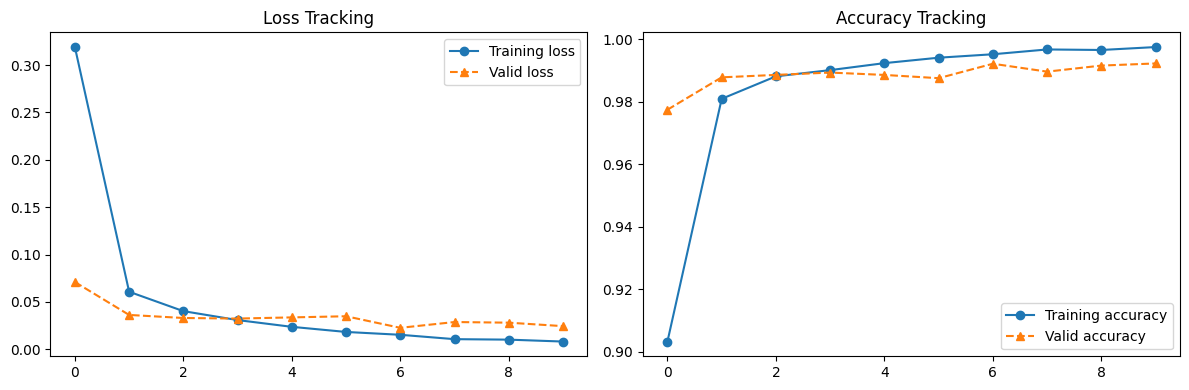

In [76]:
# plot the result
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(hist[0], '-o', label="Training loss")
ax1.plot(hist[1], '--^', label="Valid loss")
ax1.set_title("Loss Tracking")
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(hist[2], '-o', label="Training accuracy")
ax2.plot(hist[3], '--^', label="Valid accuracy")
ax2.set_title("Accuracy Tracking")
ax2.legend()

plt.legend()
plt.tight_layout()
plt.show()

# update:
- separate train/valid/test set
- write DataModule